<a href="https://colab.research.google.com/github/mohiuddinarafat17/CMAPSSData/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
!pip install shap captum tensorflow scikit-learn pandas numpy matplotlib -q

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [58]:
from google.colab import files
uploaded = files.upload()

train = pd.read_csv("train_FD002.txt", sep=r"\s+", header=None)

Saving train_FD002.txt to train_FD002 (3).txt


In [59]:
train.dropna(axis=1, inplace=True)

cols = (['engine_id','cycle'] +
        [f'op{i}' for i in range(1,4)] +
        [f's{i}' for i in range(1,22)])

train.columns = cols

In [60]:
max_cycle = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id','max_cycle']

train = train.merge(max_cycle,on='engine_id')

train['RUL'] = train['max_cycle'] - train['cycle']
train.drop('max_cycle',axis=1,inplace=True)

train['RUL'] = train['RUL'].clip(upper=125)

In [61]:
features = [c for c in train.columns if c not in ['engine_id','cycle','RUL']]

scaler = MinMaxScaler()
train[features] = scaler.fit_transform(train[features])

In [62]:
eng = train.engine_id.unique()
train_eng, val_eng = train_test_split(eng,test_size=0.2,random_state=42)

train_df = train[train.engine_id.isin(train_eng)]
val_df = train[train.engine_id.isin(val_eng)]

In [78]:
SEQ_LEN = 50

def make_seq(df):
    X, y = [], []

    for e in df.engine_id.unique():
        temp = df[df.engine_id == e]

        data = temp[features].values
        target = temp['RUL'].values

        for i in range(len(temp)-SEQ_LEN):
            X.append(data[i:i+SEQ_LEN])
            y.append(target[i+SEQ_LEN])

    return np.array(X), np.array(y)

X_train, y_train = make_seq(train_df)
X_val, y_val = make_seq(val_df)

In [79]:
cnn = Sequential([
    Conv1D(64,3,activation='relu',padding='same',input_shape=(SEQ_LEN,len(features))),
    BatchNormalization(),
    Conv1D(32,3,activation='relu',padding='same'),
    GlobalAveragePooling1D(),
    Dense(64,activation='relu'),
    Dense(1)
])

cnn.compile(optimizer='adam',loss='mse')

cnn.fit(X_train,y_train,
        validation_data=(X_val,y_val),
        epochs=50,batch_size=128)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 2190.8516 - val_loss: 2694.2920
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 648.5244 - val_loss: 2186.0845
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 608.9257 - val_loss: 620.7911
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 579.7325 - val_loss: 752.8820
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 567.4962 - val_loss: 799.6744
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 545.5876 - val_loss: 910.6264
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 534.1133 - val_loss: 1113.4602
Epoch 8/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 515.5769 - val_loss: 590.9789
Epoch 9/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 500.4897 - val_loss: 596.6327
Epoch 10/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 482.3172 - val_loss: 1046.6178
Epoch 11/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 463.1018 - val_loss: 894.9379
Ep

In [80]:
lstm = Sequential([
    LSTM(64,input_shape=(SEQ_LEN,len(features))),
    Dropout(0.2),
    Dense(32,activation='relu'),
    Dense(1)
])

lstm.compile(optimizer=tf.keras.optimizers.Adam(0.001),loss='mse')

lstm.fit(X_train,y_train,
         validation_data=(X_val,y_val),
         epochs=60,batch_size=64)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
517/517 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 2566.1851 - val_loss: 1689.4688
Epoch 2/60
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1747.1329 - val_loss: 1678.1899
Epoch 3/60
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1742.2202 - val_loss: 1679.4052
Epoch 4/60
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1739.1685 - val_loss: 1681.8243
Epoch 5/60
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1739.0581 - val_loss: 1685.2924
Epoch 6/60
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1736.6975 - val_loss: 1683.5474
Epoch 7/60
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1609.3276 - val_loss: 1241.4926
Epoch 8/60
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 971.8004 - val_loss: 844.2045
Epoch 9/60
517/517 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 851.2052 - val_loss: 767.4368
Epoch 10/60
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 814.1567 - val_loss: 802.3187
Epoch 11/60
517/517 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 800.5735 - val_loss: 690

In [81]:
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

# =====================================
# INPUT
# =====================================

inputs = Input(shape=(SEQ_LEN, len(features)))

# =====================================
# CNN PART
# =====================================

x = Conv1D(
    64,
    kernel_size=5,
    activation='relu',
    padding='same'
)(inputs)

x = BatchNormalization()(x)

x = Conv1D(
    32,
    kernel_size=3,
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

# =====================================
# LSTM PART
# =====================================

x = LSTM(
    128,
    return_sequences=True
)(x)

x = Dropout(0.2)(x)

x = LSTM(64)(x)

# =====================================
# DENSE PART
# =====================================

x = Dense(64, activation='relu')(x)

x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)

outputs = Dense(1)(x)

# =====================================
# MODEL
# =====================================

hybrid = Model(inputs, outputs)

hybrid.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='mse'
)

hybrid.summary()



Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 50, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 50, 64)         │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 50, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 50, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 50, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,417 (595.38 KB)

 Trainable params: 152,225 (594.63 KB)

 Non-trainable params: 192 (768.00 B)

In [82]:
early = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

history = hybrid.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=150,

    batch_size=32,

    callbacks=[early, lr],

    verbose=1
)

Epoch 1/150
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - loss: 3024.4167 - val_loss: 1688.6284 - learning_rate: 1.0000e-04
Epoch 2/150
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 1379.0444 - val_loss: 520.5737 - learning_rate: 1.0000e-04
Epoch 3/150
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 470.1488 - val_loss: 396.1743 - learning_rate: 1.0000e-04
Epoch 4/150
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 316.5417 - val_loss: 281.8776 - learning_rate: 1.0000e-04
Epoch 5/150
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 260.6392 - val_loss: 375.1310 - learning_rate: 1.0000e-04
Epoch 6/150
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 219.3343 - val_loss: 338.1539 - learning_rate: 1.0000e-04
Epoch 7/150
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 196.0633 - val_loss: 537.0005 - learning_rate: 1.0000e-04
Epoch 8/150
1034/1034 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 173.8292 - val_loss: 534.1084 - learning_rate: 1.0000e-04
Epoch 9/150
1

In [83]:
def eval_model(model,name):
    pred = model.predict(X_val).flatten()
    rmse = np.sqrt(mean_squared_error(y_val,pred))
    print(name,"RMSE:",rmse)
    return rmse

cnn_rmse = eval_model(cnn,"CNN")
lstm_rmse = eval_model(lstm,"LSTM")
hyb_rmse = eval_model(hybrid,"Hybrid")

241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
CNN RMSE: 21.55150095941152
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM RMSE: 17.33146999809658
241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Hybrid RMSE: 16.7892097335331


In [84]:
results = {
    "CNN": cnn_rmse,
    "LSTM": lstm_rmse,
    "Hybrid": hyb_rmse
}

print("Best:", min(results, key=results.get))
print(results)

Best: Hybrid
{'CNN': np.float64(21.55150095941152), 'LSTM': np.float64(17.33146999809658), 'Hybrid': np.float64(16.7892097335331)}


In [87]:
X_val_flat = X_val.reshape(X_val.shape[0], -1)

/tmp/ipykernel_2204/589019996.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val_flat[:200], plot_type="bar")


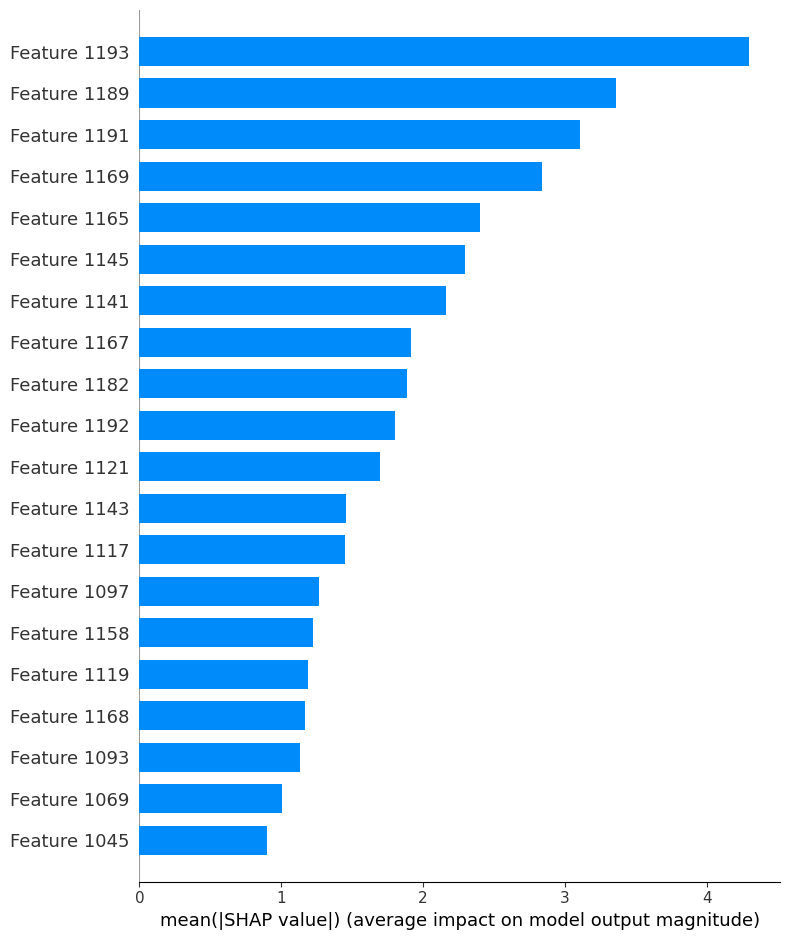

In [88]:
import shap

# Use a simple surrogate model for SHAP stability
from xgboost import XGBRegressor

surrogate = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)

surrogate.fit(X_val_flat, y_val)

explainer = shap.Explainer(surrogate)
shap_values = explainer(X_val_flat[:200])

shap.summary_plot(shap_values, X_val_flat[:200], plot_type="bar")

/tmp/ipykernel_2204/1353494193.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val_flat[:200])


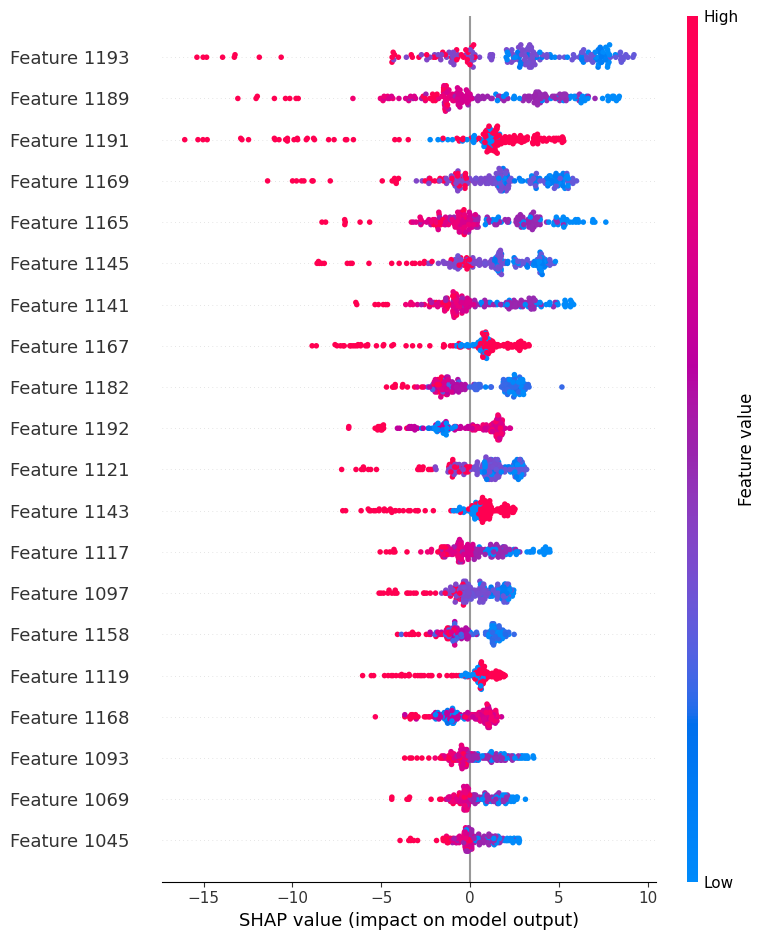

In [89]:
shap.summary_plot(shap_values, X_val_flat[:200])

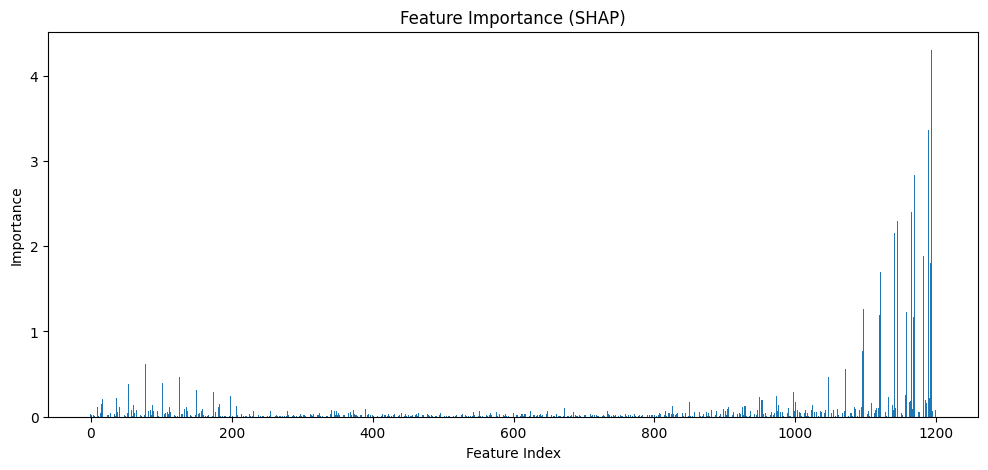

In [90]:
import numpy as np
import matplotlib.pyplot as plt

importance = np.mean(np.abs(shap_values.values), axis=0)

plt.figure(figsize=(12,5))
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance (SHAP)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


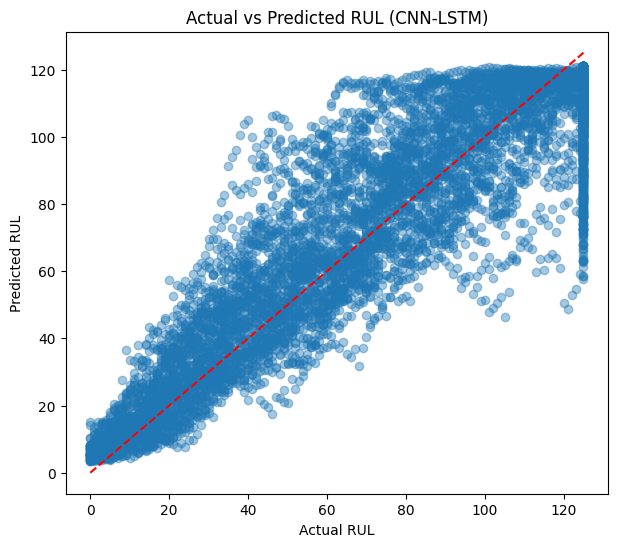

In [91]:
pred = hybrid.predict(X_val).flatten()

plt.figure(figsize=(7,6))
plt.scatter(y_val, pred, alpha=0.4)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL (CNN-LSTM)")
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--')
plt.show()

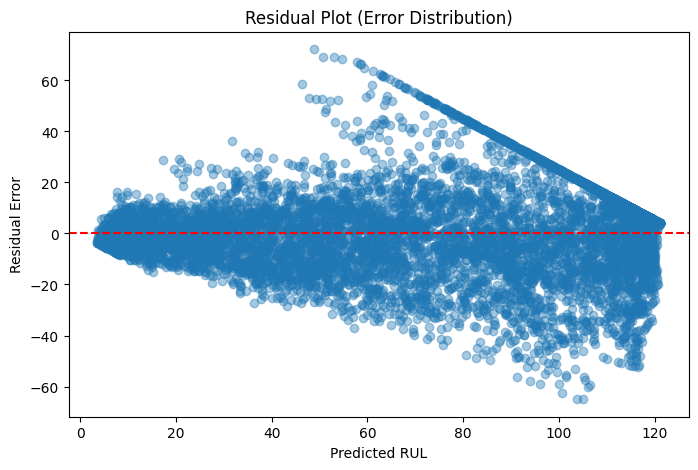

In [92]:
residuals = y_val - pred

plt.figure(figsize=(8,5))
plt.scatter(pred, residuals, alpha=0.4)

plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel("Predicted RUL")
plt.ylabel("Residual Error")
plt.title("Residual Plot (Error Distribution)")
plt.show()

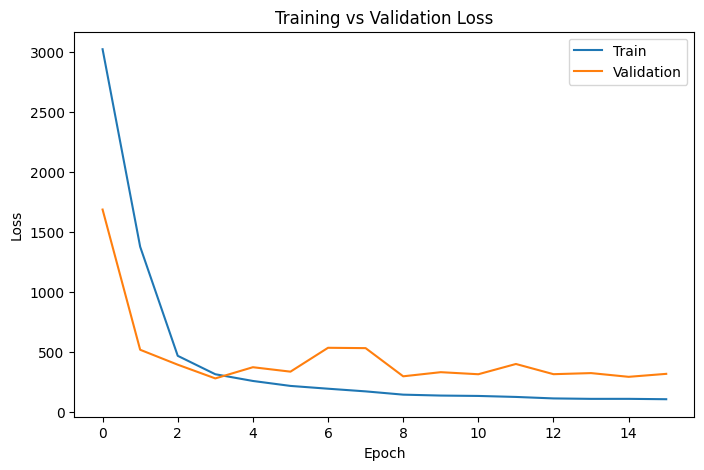

In [93]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

In [94]:
import tensorflow as tf

def integrated_gradients(model, x, steps=30):
    baseline = np.zeros_like(x)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    baseline = tf.convert_to_tensor(baseline, dtype=tf.float32)

    total_grads = 0

    for i in range(steps):
        alpha = i / steps
        interpolated = baseline + alpha * (x - baseline)

        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            pred = model(tf.expand_dims(interpolated, 0))

        grads = tape.gradient(pred, interpolated)
        total_grads += grads

    avg_grads = total_grads / steps
    return (x - baseline) * avg_grads

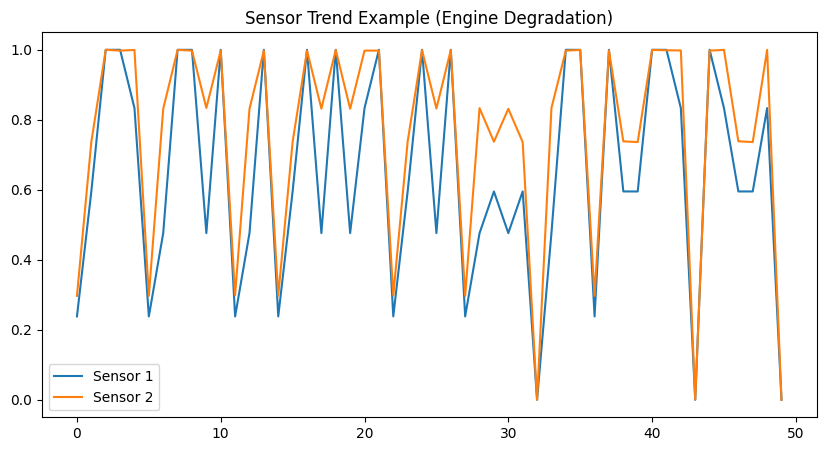

In [95]:
plt.figure(figsize=(10,5))

plt.plot(X_val[0][:,0], label="Sensor 1")
plt.plot(X_val[0][:,1], label="Sensor 2")

plt.title("Sensor Trend Example (Engine Degradation)")
plt.legend()
plt.show()

new

In [96]:
cnn_pred = cnn.predict(X_val).flatten()
lstm_pred = lstm.predict(X_val).flatten()
hybrid_pred = hybrid.predict(X_val).flatten()

241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [97]:
from sklearn.metrics import mean_squared_error
import numpy as np

cnn_rmse = np.sqrt(mean_squared_error(y_val, cnn_pred))
lstm_rmse = np.sqrt(mean_squared_error(y_val, lstm_pred))
hybrid_rmse = np.sqrt(mean_squared_error(y_val, hybrid_pred))

results = {
    "CNN": cnn_rmse,
    "LSTM": lstm_rmse,
    "CNN-LSTM Hybrid": hybrid_rmse
}

print(results)

{'CNN': np.float64(21.55150095941152), 'LSTM': np.float64(17.33146999809658), 'CNN-LSTM Hybrid': np.float64(16.7892097335331)}


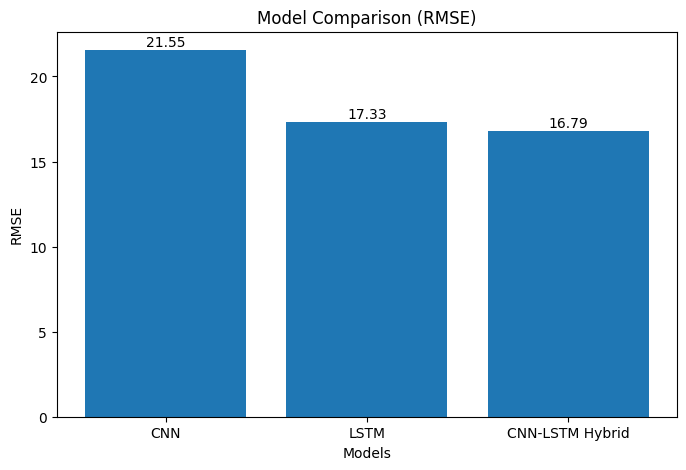

In [98]:
import matplotlib.pyplot as plt

models = list(results.keys())
rmse_values = list(results.values())

plt.figure(figsize=(8,5))
plt.bar(models, rmse_values)

plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Models")

for i, v in enumerate(rmse_values):
    plt.text(i, v + 0.2, f"{v:.2f}", ha='center')

plt.show()

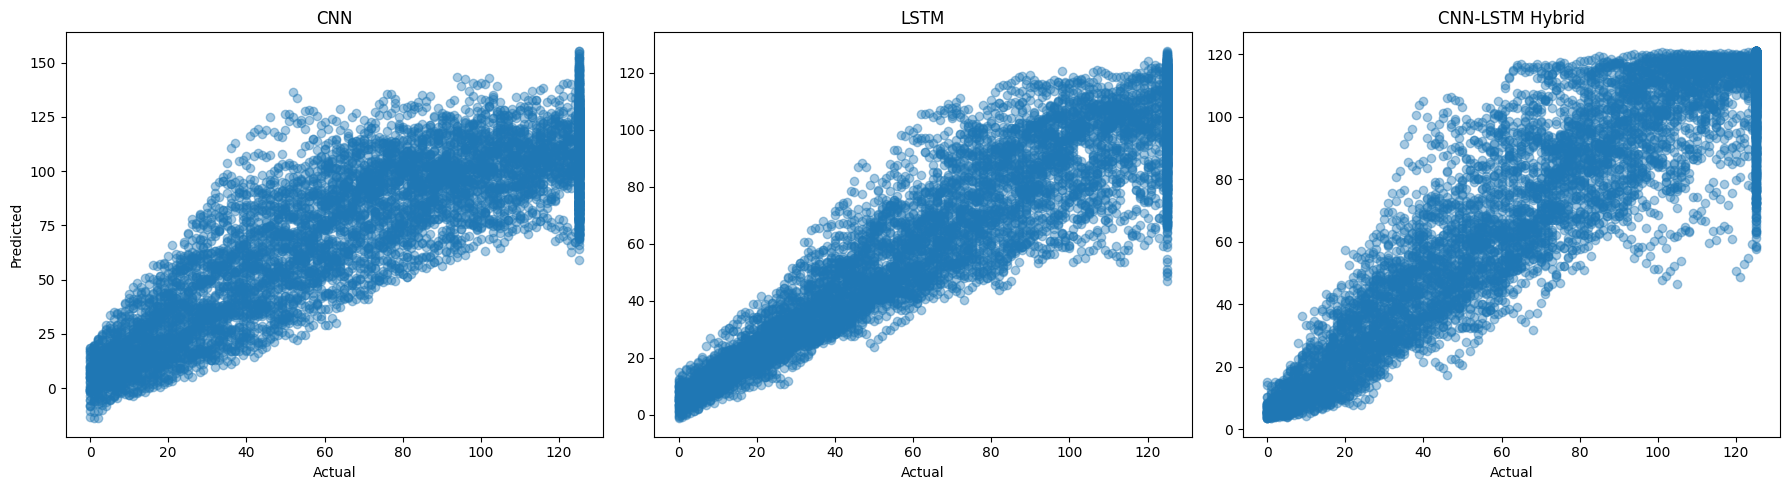

In [99]:
plt.figure(figsize=(18,5))

# CNN
plt.subplot(1,3,1)
plt.scatter(y_val, cnn_pred, alpha=0.4)
plt.title("CNN")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# LSTM
plt.subplot(1,3,2)
plt.scatter(y_val, lstm_pred, alpha=0.4)
plt.title("LSTM")
plt.xlabel("Actual")

# Hybrid
plt.subplot(1,3,3)
plt.scatter(y_val, hybrid_pred, alpha=0.4)
plt.title("CNN-LSTM Hybrid")
plt.xlabel("Actual")

plt.tight_layout()
plt.show()

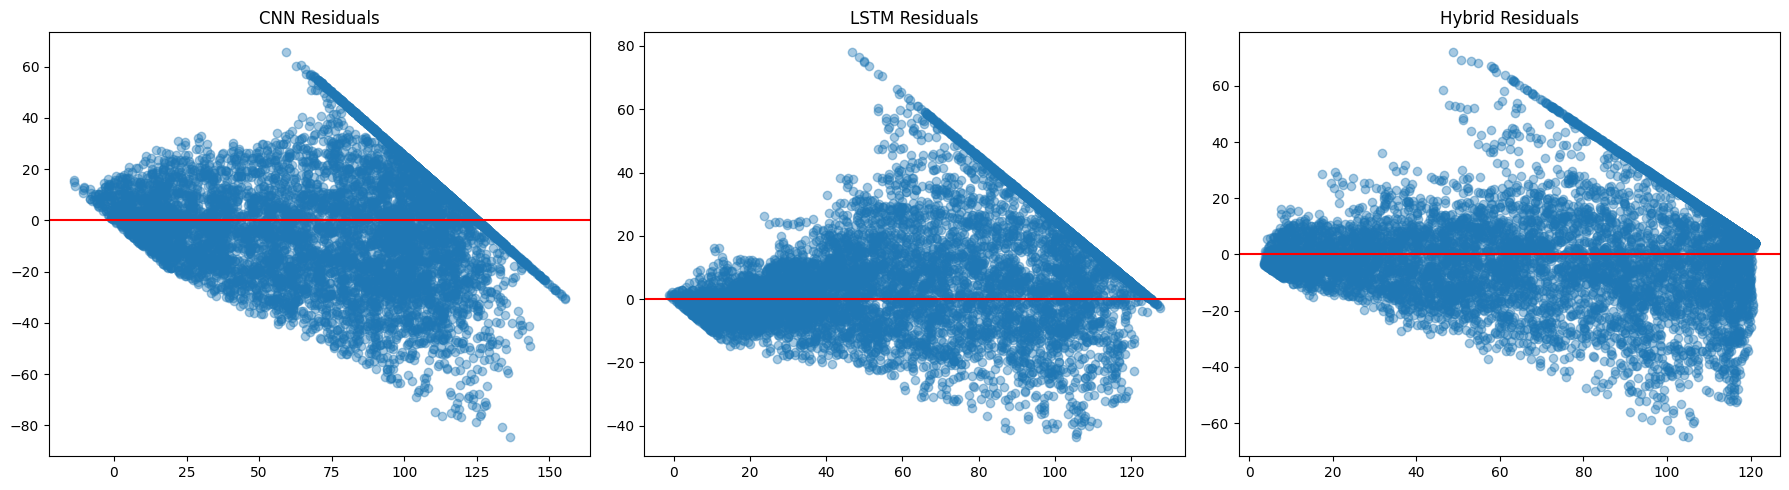

In [100]:
cnn_res = y_val - cnn_pred
lstm_res = y_val - lstm_pred
hybrid_res = y_val - hybrid_pred

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.scatter(cnn_pred, cnn_res, alpha=0.4)
plt.axhline(0,color='r')
plt.title("CNN Residuals")

plt.subplot(1,3,2)
plt.scatter(lstm_pred, lstm_res, alpha=0.4)
plt.axhline(0,color='r')
plt.title("LSTM Residuals")

plt.subplot(1,3,3)
plt.scatter(hybrid_pred, hybrid_res, alpha=0.4)
plt.axhline(0,color='r')
plt.title("Hybrid Residuals")

plt.tight_layout()
plt.show()

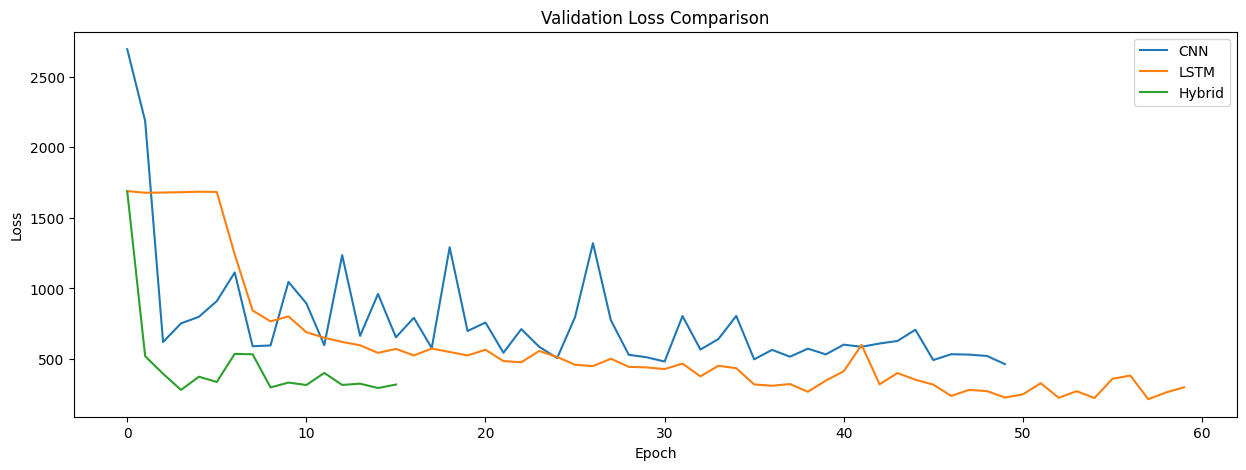

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# CNN loss
plt.plot(cnn.history.history['val_loss'], label="CNN")

# LSTM loss
plt.plot(lstm.history.history['val_loss'], label="LSTM")

# Hybrid loss
plt.plot(hybrid.history.history['val_loss'], label="Hybrid")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [102]:
best_model = min(results, key=results.get)

print("=================================")
print("BEST MODEL:", best_model)
print("=================================")
print(results)

BEST MODEL: CNN-LSTM Hybrid
{'CNN': np.float64(21.55150095941152), 'LSTM': np.float64(17.33146999809658), 'CNN-LSTM Hybrid': np.float64(16.7892097335331)}
